In [2]:
import numpy as np
import polars as pl
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pl.DataFrame({
    "StudyHours": np.random.uniform(1, 10, 100),
    "Attendance": np.random.randint(50, 100, 100),
    "City": np.random.choice(["Delhi", "Mumbai", "Pune"], 100),
    "G3_Score": np.random.uniform(5, 20, 100)
})

X = df.drop("G3_Score").to_pandas()
y = df["G3_Score"].to_numpy()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["StudyHours", "Attendance"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["City"])
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, preds):.2f}")
print(f"MSE: {mean_squared_error(y_test, preds):.2f}")
print(f"MAE: {mean_absolute_error(y_test, preds):.2f}")
print("df.head():")
print(df.head())

R2 Score: -0.56
MSE: 25.52
MAE: 4.01
df.head():
shape: (5, 4)
┌────────────┬────────────┬────────┬───────────┐
│ StudyHours ┆ Attendance ┆ City   ┆ G3_Score  │
│ ---        ┆ ---        ┆ ---    ┆ ---       │
│ f64        ┆ i32        ┆ str    ┆ f64       │
╞════════════╪════════════╪════════╪═══════════╡
│ 5.725394   ┆ 74         ┆ Delhi  ┆ 5.672203  │
│ 8.500584   ┆ 60         ┆ Pune   ┆ 12.652373 │
│ 2.265975   ┆ 69         ┆ Delhi  ┆ 19.642349 │
│ 8.029136   ┆ 85         ┆ Mumbai ┆ 16.964946 │
│ 9.109567   ┆ 56         ┆ Pune   ┆ 15.918507 │
└────────────┴────────────┴────────┴───────────┘


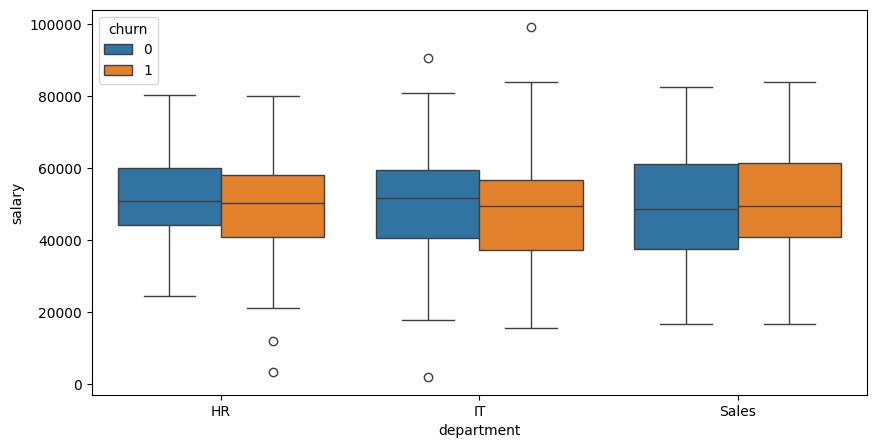

              precision    recall  f1-score   support

           0       0.62      0.41      0.49        58
           1       0.44      0.64      0.52        42

    accuracy                           0.51       100
   macro avg       0.53      0.53      0.51       100
weighted avg       0.54      0.51      0.51       100



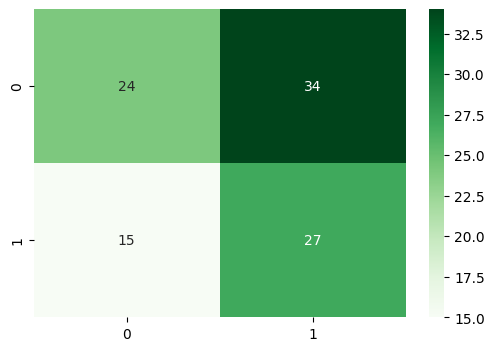

In [3]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix

df = pl.DataFrame({
    "age": np.random.randint(18, 65, 500),
    "salary": np.random.normal(50000, 15000, 500),
    "department": np.random.choice(["Sales", "IT", "HR"], 500),
    "churn": np.random.randint(0, 2, 500)
})

plt.figure(figsize=(10, 5))
sns.boxplot(data=df.to_pandas(), x="department", y="salary", hue="churn")
plt.show()

X = df.drop("churn").to_pandas()
y = df["churn"].to_numpy()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["age", "salary"]),
        ("cat", OneHotEncoder(), ["department"])
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

print(classification_report(y_test, preds))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Greens')
plt.show()